In [1]:
import os
import shutil
import subprocess
import pandas as pd
import fastparquet
import kagglehub

DATA_DIR = "data"
CSV_FILE = os.path.join(DATA_DIR, "trending_yt_videos_113_countries.csv")
PARQUET_FILE = os.path.join(DATA_DIR, "youtube_data.parquet")
os.makedirs(DATA_DIR, exist_ok=True)

/Users/sophia/Documents/GitHub/DeeplearningFinalUwU/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if not os.path.exists(PARQUET_FILE) and not os.path.exists(CSV_FILE):
    print("Dataset not found locally. Downloading from Kaggle...")
    cache_path = kagglehub.dataset_download("asaniczka/trending-youtube-videos-113-countries/versions/852")
    
    # Find the CSV in the Kaggle cache and copy it to our data folder
    for file in os.listdir(cache_path):
        if file.endswith(".csv"):
            shutil.copy(os.path.join(cache_path, file), CSV_FILE)
            print(f"Successfully moved CSV to {CSV_FILE}")
else:
    print("CSV or Parquet already exists! Skipping download...........")

Dataset not found locally. Downloading from Kaggle...


100%|██████████| 2.25G/2.25G [01:50<00:00, 21.9MB/s]

Extracting files...


Successfully moved CSV to data/trending_yt_videos_113_countries.csv


In [3]:
if not os.path.exists(PARQUET_FILE):
    print("Parquet file not found! preprocessing.........")
    result = subprocess.run(["python3", "process.py"], capture_output=True, text=True)
    
    if result.returncode == 0:
        print(result.stdout)
    else:
        print(result.stderr)
else:
    print("Parquet already exists! Ready!!!!")

Parquet file not found! preprocessing.........



In [4]:
df = pd.read_parquet(PARQUET_FILE)

print(f"DataFrame Shape: {df.shape}")
df.head()

DataFrame Shape: (4747142, 18)


,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,description,video_id,channel_id,video_tags,kind,publish_date,langauge,like_tier
0,Nyasha David - Tsvodi (Official Music Video),Nyasha David,1,0,15,2026-02-18,ZW,430573,13860,1139,#Tsvodi #nyashadavid #mafindifuva \n\nSong Pro...,07pinMbPq2Q,UCx1LPxEtJWIpvtXTYadAdKg,,youtube#video,2026-02-09,und,pretty_viral
1,WAR MACHINE | Official Trailer | Netflix,Netflix,2,0,0,2026-02-18,ZW,12531660,191591,15336,During the final stage of U.S. Army Ranger sel...,AFuE1LRxm80,UCWOA1ZGywLbqmigxE4Qlvuw,"Alan Ritchson, Alan Ritchson War Machine, Armo...",youtube#video,2026-02-04,en-US,really_viral
2,10 Seconds vs 1 Hour MODERN MOUNTAIN HOUSE Bui...,Cash,3,0,47,2026-02-18,ZW,491455,6139,1656,Instagram: https://www.instagram.com/cashmarco...,EbBjlznDwzk,UC0eLBYhxW9HC0P9PXQ73mpQ,"Cash, Nico, Nico and Cash, Cash and Nico, Mine...",youtube#video,2026-02-16,en-US,a_little_viral
3,Master H - Impossible (Official Music Video),Master H,4,0,3,2026-02-18,ZW,532388,14552,1281,Artist : Master H\nSong : Impossible \nProduce...,TIG5IzusQ24,UC5jrU8WxzE16gPTnlqQAqew,,youtube#video,2026-02-06,en,pretty_viral
4,“Spider-Noir” – Authentic Black & White Teaser...,Prime Video,5,0,45,2026-02-18,ZW,13406903,239798,10614,"With no power comes no responsibility. ""Spider...",HgMbkitzhEM,UCQJWtTnAHhEG5w4uN0udnUQ,"spider noir official teaser, spider noir tease...",youtube#video,2026-02-12,en,really_viral


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4747142 entries, 0 to 4747141
Data columns (total 18 columns):
 #   Column           Dtype         
---  ------           -----         
 0   title            object        
 1   channel_name     object        
 2   daily_rank       uint8         
 3   daily_movement   int16         
 4   weekly_movement  int16         
 5   snapshot_date    datetime64[us]
 6   country          object        
 7   view_count       int64         
 8   like_count       int32         
 9   comment_count    int32         
 10  description      object        
 11  video_id         object        
 12  channel_id       object        
 13  video_tags       object        
 14  kind             object        
 15  publish_date     datetime64[us]
 16  langauge         object        
 17  like_tier        object        
dtypes: datetime64[us](2), int16(2), int32(2), int64(1), object(10), uint8(1)
memory usage: 529.7+ MB


In [6]:
df.shape
df.describe()

,daily_rank,daily_movement,weekly_movement,snapshot_date,view_count,like_count,comment_count,publish_date
count,4.747142e+06,4.747142e+06,4.747142e+06,4747142,4.747142e+06,4.747142e+06,4.747142e+06,4747142
mean,2.544879e+01,2.704673e+00,1.726932e+01,2024-12-21 02:29:18.085180,1.055349e+07,3.259516e+05,6.881398e+03,2024-12-14 17:56:09.078039
min,1.000000e+00,-4.900000e+01,-4.900000e+01,2023-10-26 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,2023-09-20 02:22:46
25%,1.300000e+01,-8.000000e+00,4.000000e+00,2024-05-24 00:00:00,3.185920e+05,8.830000e+03,2.920000e+02,2024-05-18 00:00:00
50%,2.500000e+01,-1.000000e+00,2.000000e+01,2024-12-21 00:00:00,1.305670e+06,4.323500e+04,1.089000e+03,2024-12-14 00:00:00
75%,3.800000e+01,1.200000e+01,3.500000e+01,2025-07-19 00:00:00,8.235680e+06,2.519460e+05,3.624000e+03,2025-07-12 00:00:00
max,5.000000e+01,4.900000e+01,4.900000e+01,2026-02-18 00:00:00,1.407108e+09,1.576806e+07,6.493188e+06,2026-02-18 00:00:00
std,1.442901e+01,1.862639e+01,2.203937e+01,NaN,2.440221e+07,7.961383e+05,4.944094e+04,NaN


In [7]:
df.sample(5)


,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,description,video_id,channel_id,video_tags,kind,publish_date,langauge,like_tier
1379743,IZNENADIO SAM TAKSISTU IZ EGIPTA ZA RODJENDAN!,Simi,43,-1,7,2025-06-15,ME,214770,18775,835,(Samo za nove korisnike Temu aplikacije) - Pre...,4LWXHVSC5M4,UCgh8IAvIz1mxWMdCtiiVJBg,,youtube#video,2025-06-10,,pretty_viral
562019,Juan Luis Guerra 4.40 - Estrellitas y Duendes ...,Juan Luis Guerra,29,-3,21,2025-11-09,PA,1103173,75218,5517,Juan Luis Guerra 4.40 - Estrellitas y Duendes ...,gl3Z28ygq4s,UC5j34OS3TkHQyk4aPFiV5Sg,"juan luis guerra, 440, jlg, album juan luis gu...",youtube#video,2025-11-07,es,really_viral
2292273,Tui là….ai #shorts #tkh0112 #huykhang,Huy Khang,40,-8,10,2025-01-04,VN,1741034,38667,82,"✔ Đăng ký kênh Huy Khang, Like và Nhấn chuông ...",zGwKnA17IAw,UCir4cu2u6q8vK7hOBNjpGEg,"huy khang, huykhangtran119, huy khang tiktok, ...",youtube#video,2024-12-25,,pretty_viral
3121141,Joker can't swim!#joker #shorts,Untitled Joker,20,-5,30,2024-08-11,CZ,18863170,340096,534,"We hope you have a good time with our videos, ...",MGwjB1sJhvY,UCPE_UIuGbfeZSEnFE1WI-Gg,"#shorts, #joker, #funny, cosplay",youtube#video,2024-08-07,,super_viral
1836299,ADIVINA EL JUGADOR (ACTUAL O LEYENDA) VS. DAVO...,LA COBRA,43,-7,7,2025-03-26,PE,580239,28521,790,No te olvides suscribirte y activar las notifi...,ATmuOprBZV8,UCCfPkh8osJPC2pPq283kKXg,"la cobra, futbol, argentina, twitch, the last ...",youtube#video,2025-03-20,es-419,pretty_viral


In [8]:
df.isna().sum()


title              0
channel_name       0
daily_rank         0
daily_movement     0
weekly_movement    0
snapshot_date      0
country            0
view_count         0
like_count         0
comment_count      0
description        0
video_id           0
channel_id         0
video_tags         0
kind               0
publish_date       0
langauge           0
like_tier          0
dtype: int64

In [9]:
df.duplicated().sum()


np.int64(0)

In [10]:
df['publish_date'] = pd.to_datetime(df['publish_date'])
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

# Get the oldest date
oldest_date = df['publish_date'].min()

# Get the newest date
newest_date = df['publish_date'].max()

print(f"Oldest: {oldest_date}")
print(f"Newest: {newest_date}")

Oldest: 2023-09-20 02:22:46
Newest: 2026-02-18 00:00:00


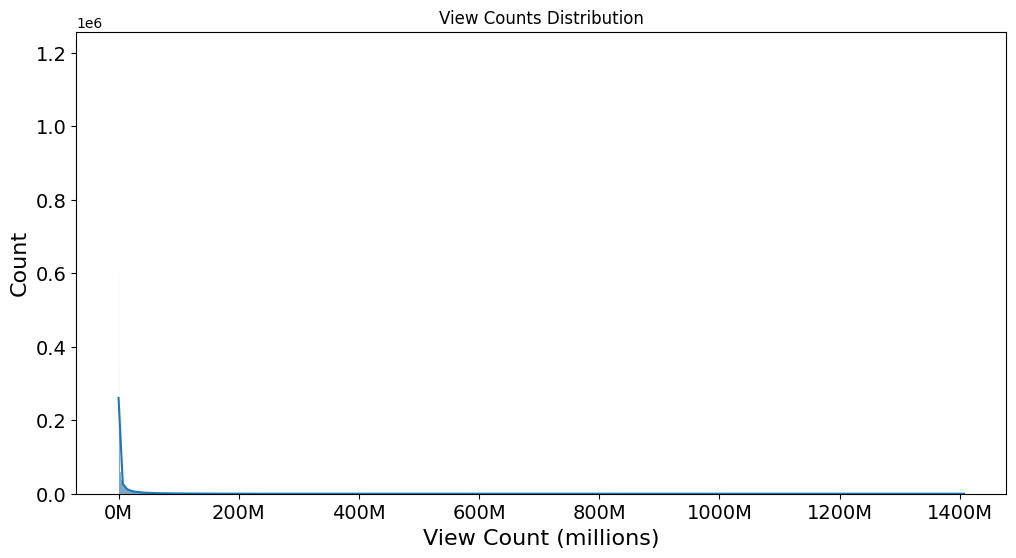

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


df['publish_month'] = df['publish_date'].dt.month
df['publish_day'] = df['publish_date'].dt.day
df['publish_year'] = df['publish_date'].dt.year

plt.figure(figsize=(12,6))
sns.histplot(df['view_count'], kde=True)
plt.title('View Counts Distribution')

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('View Count (millions)', fontsize=16)
plt.ylabel('Count', fontsize=16)

plt.show()

We can see that majority of the videos are usually seen around 0-5 million views. This isn't normally distributed as we can see, and that it's skewed right heavily.

/Users/sophia/Documents/GitHub/DeeplearningFinalUwU/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


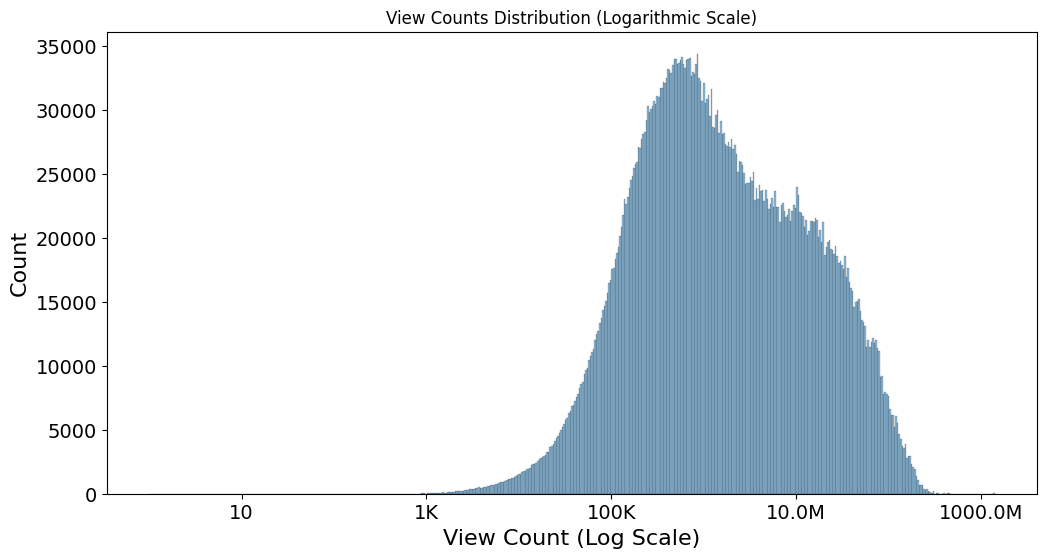

In [12]:
plt.figure(figsize=(12, 6))
ax = plt.gca() 

sns.histplot(df['view_count'], kde=True, log_scale=True)

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('View Count (Log Scale)', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.title('View Counts Distribution (Logarithmic Scale)')

plt.show()

On a logarithmic scale, we can see that it's much closer to being normally distributed. The median point seems to be around 3 million views.

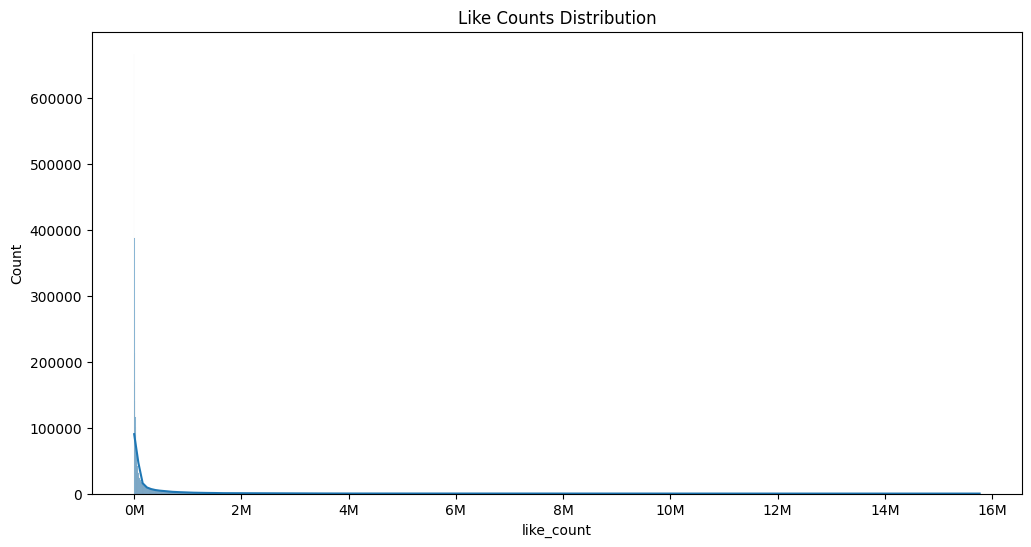

In [13]:
plt.figure(figsize=(12, 6))
ax = plt.gca() 
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

sns.histplot(df['like_count'], kde=True)
plt.title('Like Counts Distribution')
plt.show()

Again, this isn't normally distributed and is heavily skewed to the right. The maximum amount of likes is around 16 million.

/Users/sophia/Documents/GitHub/DeeplearningFinalUwU/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


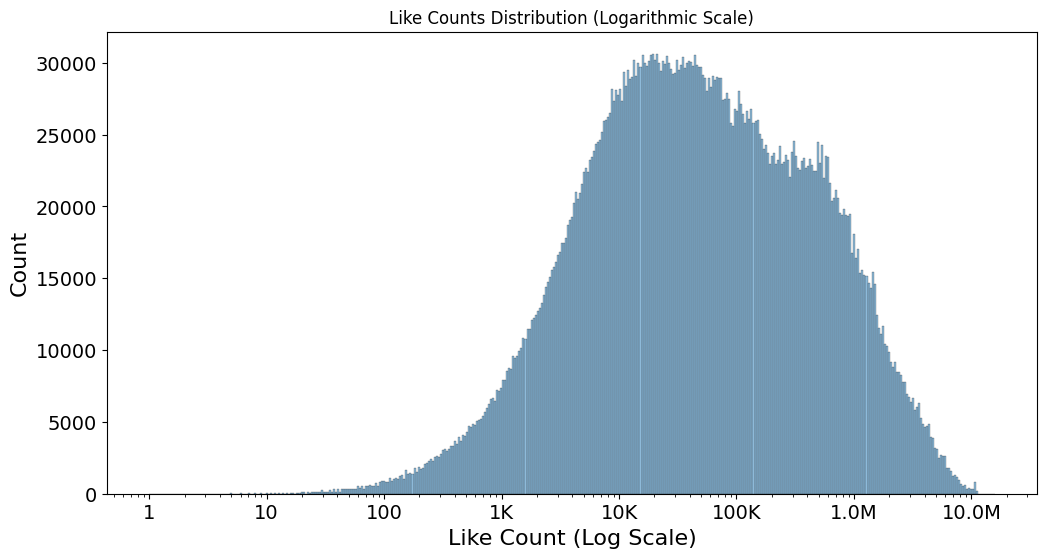

In [14]:
plt.figure(figsize=(12, 6))
ax = plt.gca() 

sns.histplot(df['like_count'], kde=True, log_scale=True)

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Like Count (Log Scale)', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.title('Like Counts Distribution (Logarithmic Scale)')

plt.show()

So we convert it into logarithmic scale and we see that the median point is between 10 - 100k likes.

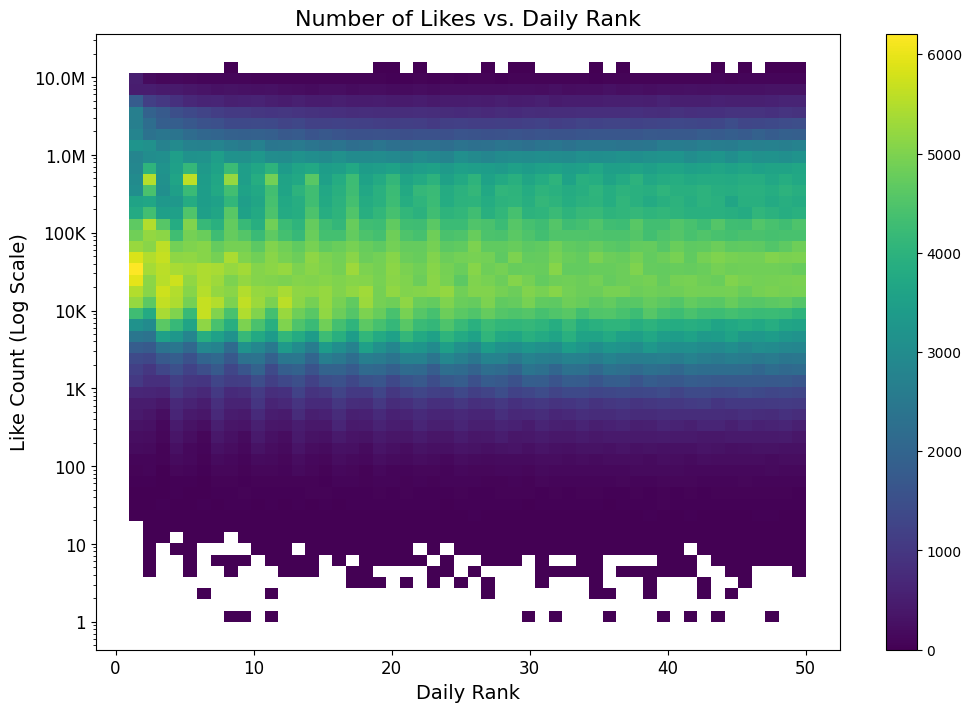

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np

plt.figure(figsize=(12, 8))

df_filtered = df[df['like_count'] > 0]

sns.histplot(
    data=df_filtered, 
    x='daily_rank', 
    y='like_count', 
    log_scale=(False, True),
    bins=50, 
    cbar=True,
    cmap='viridis'
)

ax = plt.gca()

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

plt.title('Number of Likes vs. Daily Rank', fontsize=16)
plt.xlabel('Daily Rank', fontsize=14)
plt.ylabel('Like Count (Log Scale)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

The colors signify the number of videos, and so we see that towards the bottom of the visualization, that there are less videos who have a lower like count based on their daily ranks. Most of the videos on the higher end recieve around 10 - 100k lieks when their daily rank reaches 1, which is why the most left of the visualization is a lot more concentrated in yellow.

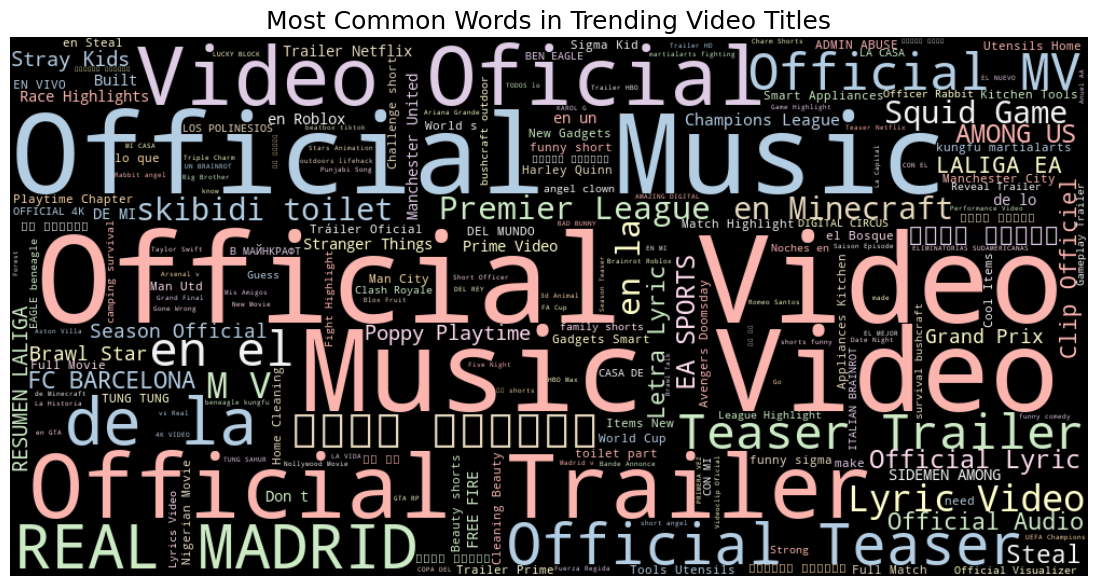

In [16]:
import plotly.express as px
from wordcloud import WordCloud


text = ' '.join(df['title'].dropna().astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color='black', colormap='Pastel1').generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Trending Video Titles", fontsize=18)
plt.show()

The top five words that pop up in trending video titles we found were Official, Video, Trailer, Music, and Teaser.

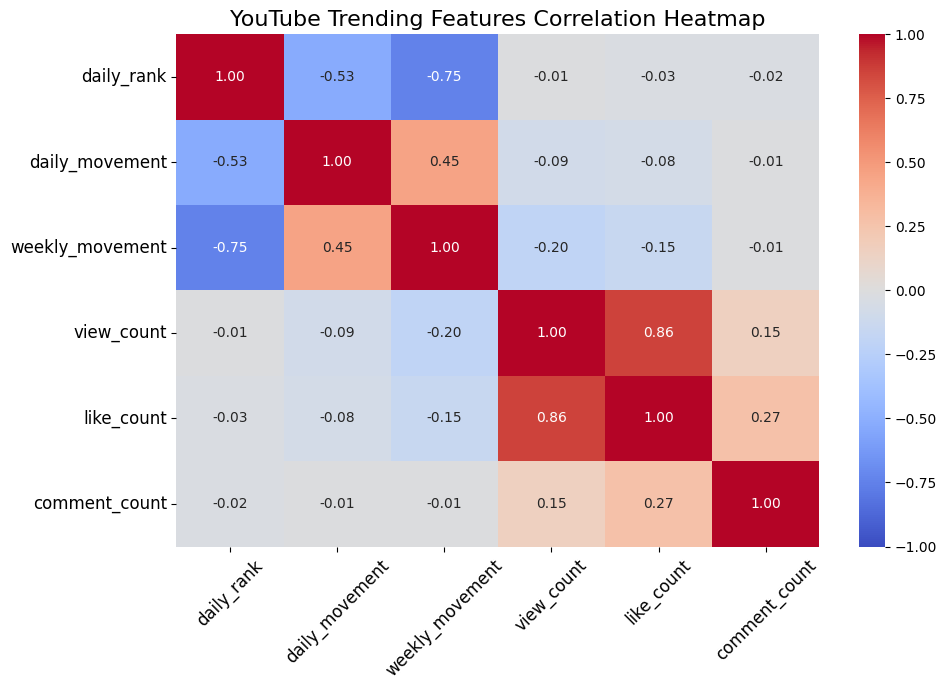

In [17]:
corr_df = df[["daily_rank", "daily_movement", "weekly_movement", "view_count", "like_count", "comment_count"]]

corr_matrix = corr_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("YouTube Trending Features Correlation Heatmap", fontsize=16)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

Looking at this heatmap, we see there is high positive linear correlation between features view_count and like_count. There's also a moderately positive correlation between daily_movement and weekly_movement. This means that as view count increases, so does like count and vice versa. And when there's more daily movement, that will also help weekly movement increase as well.

Now for the other features. There's a moderate to strong negative correlation between weekly_movement and daily_rank on the other hand and between daily_movement and daily_rank. This means that as daily rank goes down, the weekly and daily movements go up. This at first may sound pretty bad, but we have to remind ourselves that the smaller than rank number is (such as 1) is better than a big number ranking such as 10.

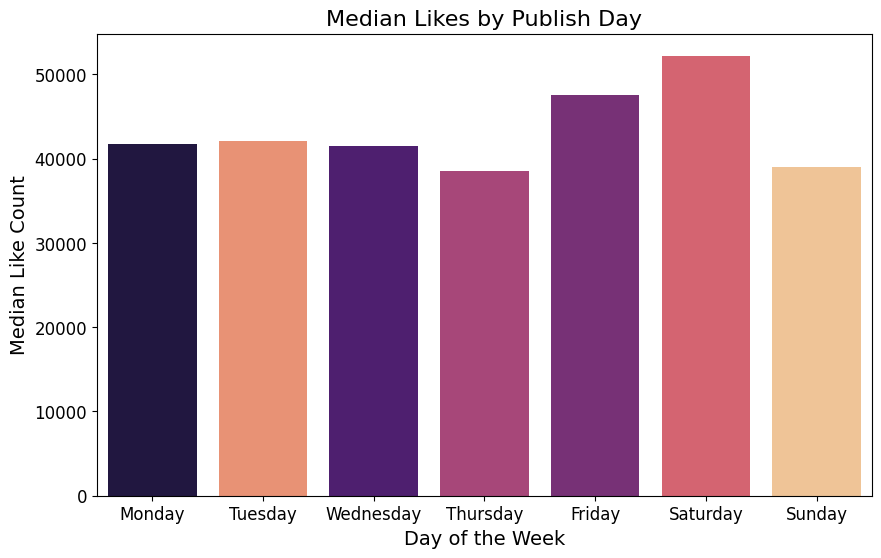

In [18]:
import pandas as pd

df['publish_day_of_week'] = df['publish_date'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df, 
    x='publish_day_of_week', 
    y='like_count', 
    order=days_order,
    estimator='median',
    errorbar=None,
    hue='publish_day_of_week',
    palette='magma',
    legend=False
)

plt.title('Median Likes by Publish Day', fontsize=16)
plt.xlabel('Day of the Week', fontsize=14)
plt.ylabel('Median Like Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

We can see that the tendency of the day that has most number of likes is Saturday, though the average median like count for the seven days seem to be pretty consistent of around 40 thousand.

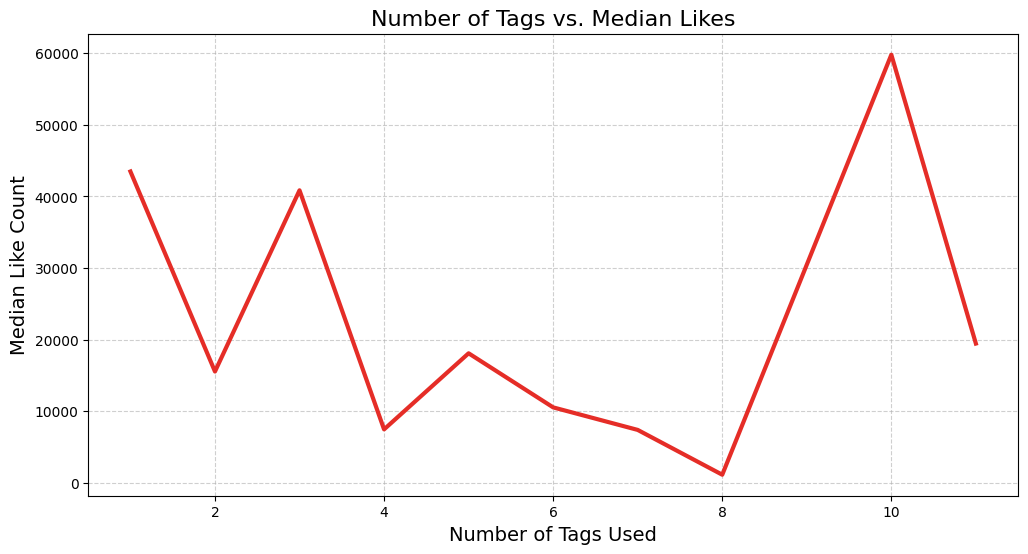

In [19]:
import numpy as np

df['tag_count'] = df['video_tags'].astype(str).str.split('|').str.len().fillna(0)
tag_grouped = df.groupby('tag_count')['like_count'].median().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=tag_grouped, 
    x='tag_count', 
    y='like_count', 
    linewidth=3,
    color='#e52d27'
)

plt.title('Number of Tags vs. Median Likes', fontsize=16)
plt.xlabel('Number of Tags Used', fontsize=14)
plt.ylabel('Median Like Count', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Based on the graph we can see that there's not a distinct pattern in the number of tags versus the number of likes a video has because of the inconsistent peaks and dips. For example, when a video has 8 tags, videos tend to receive an average of 10k likes. But when 10 tags are used, 60k is the new average. This means this feature isn't making a strong or direct impact on user likes.

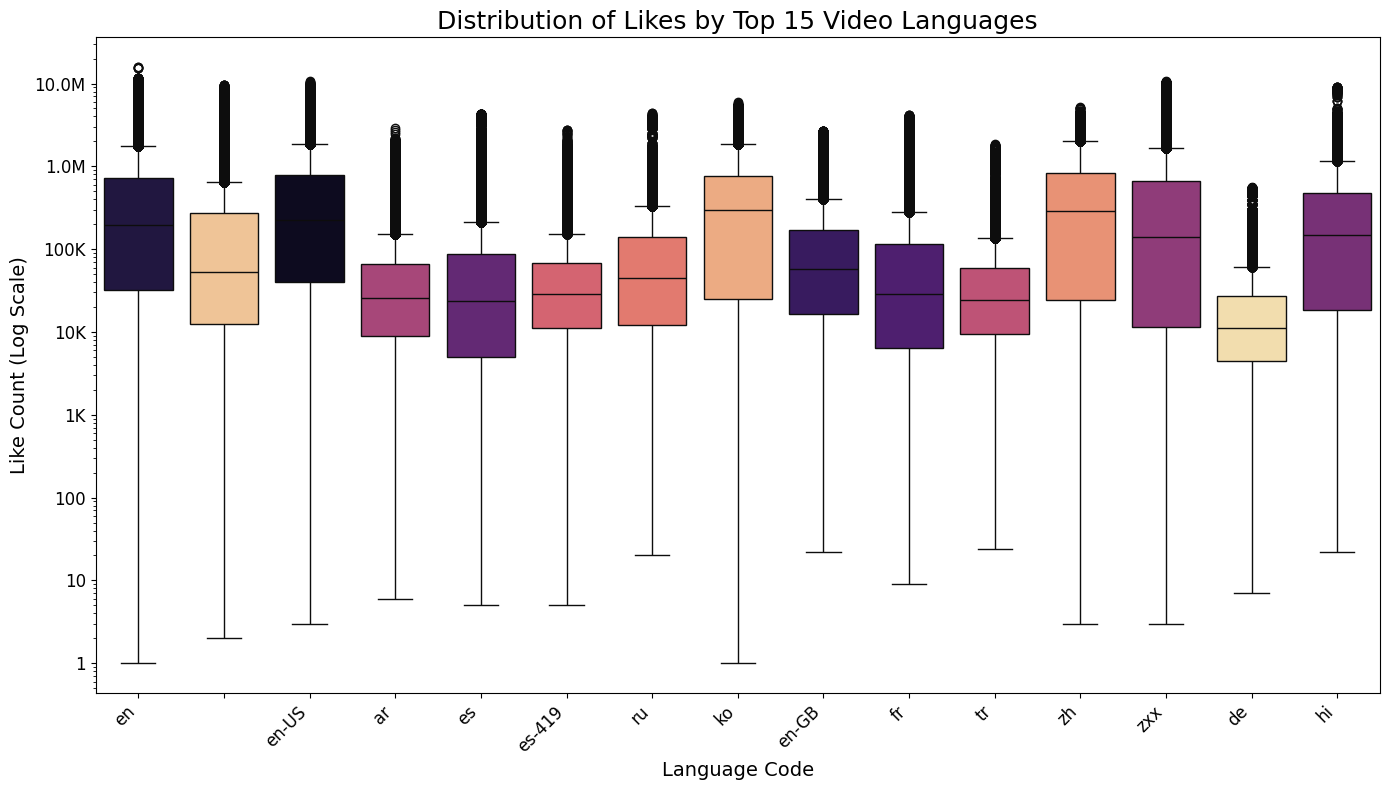

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

top_15_languages = df['langauge'].value_counts().nlargest(15).index
df_filtered = df[(df['langauge'].isin(top_15_languages)) & (df['like_count'] > 0)]

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df_filtered, 
    x='langauge', 
    y='like_count', 
    order=top_15_languages,
    hue='langauge',
    palette='magma',
    legend=False
)

ax = plt.gca()

ax.set_yscale('log')

def human_readable_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{x:.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(human_readable_format))

plt.title('Distribution of Likes by Top 15 Video Languages', fontsize=18)
plt.xlabel('Language Code', fontsize=14)
plt.ylabel('Like Count (Log Scale)', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

There aren't huge differences in like counts based on countries - we can see that the overall average in like counts for all countries is within the range of 10k to 1 million.

There are a lot of outliers but we are going to keep them because they are all part of the human behavior interaction of likes and represent cases of insane high viral video trends. 